# Full Hugging Face → File-level Streaming → Behavioral SVD Pipeline

Notebook đầy đủ từ đầu:
1. Download từng zip từ Hugging Face.
2. Không unzip cả folder.
3. Extract từng `.parquet` một file tạm.
4. Spark đọc, lọc toxic political amplified messages.
5. Append output cuối.
6. Chạy Behavioral SVD/PCA + KMeans clustering.

In [1]:
!pip -q install pyspark tqdm pandas matplotlib

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("full-hf-filelevel-behavioral-svd")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/04 10:05:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
from pathlib import Path
import gc, shutil, subprocess, zipfile
from tqdm.auto import tqdm

from pyspark.sql.functions import (
    col, length, to_timestamp, log1p, coalesce, lit,
    avg, count, max as spark_max
)

HF_BASE = "https://huggingface.co/datasets/Tungtom2004/Telegram_politic_dataset/resolve/main"

BASE = Path("/kaggle/working/data")
RAW = BASE / "raw_tmp"
TMP = BASE / "parquet_tmp"
FINAL = BASE / "final" / "toxic_political_amplified_filelevel"

RAW.mkdir(parents=True, exist_ok=True)
TMP.mkdir(parents=True, exist_ok=True)
FINAL.parent.mkdir(parents=True, exist_ok=True)

ZIP_FILES = [
    "channels_10_parquet.zip",
    "channels_11_parquet.zip",
    "channels_12_parquet.zip",
    "channels_13_parquet.zip",
    "channels_14_parquet.zip",
    "channels_15_parquet.zip",
    "channels_16_parquet.zip",
    "channels_17_parquet.zip",
    "channels_18_parquet.zip",
    "channels_19_parquet.zip",
    "channels_20_parquet.zip",
    "channels_21_parquet.zip",
    "channels_22_parquet.zip",
    "channels_23_parquet.zip",
    "channels_24_parquet.zip",
]

KEEP_COLS = [
    "content", "language", "date", "political",
    "toxicity", "severe_toxicity", "identity_attack",
    "insult", "profanity", "threat", "forwards",
]

RESET_OUTPUT = False

MIN_CONTENT_LENGTH = 30
MIN_FORWARDS = 3
MIN_TOXICITY = 0.2

SPAM_REGEX = "(?i)(http|www|vip|deposit|register|bonus|usdt|airdrop|referral|withdrawal|claim|earn)"

print("Output path:", FINAL)

Output path: /kaggle/working/data/final/toxic_political_amplified_filelevel


In [4]:
def free_gb(path="/kaggle/working"):
    return shutil.disk_usage(path).free / 1e9

def run_quiet(cmd):
    result = subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        raise RuntimeError(result.stderr[:2000])

def safe_remove_file(path):
    path = Path(path)
    if path.exists():
        path.unlink()

def safe_remove_dir(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path, ignore_errors=True)

def cleanup_temp():
    safe_remove_dir(TMP)
    TMP.mkdir(parents=True, exist_ok=True)
    spark.catalog.clearCache()
    gc.collect()

def download_zip(zip_name):
    zip_path = RAW / zip_name
    safe_remove_file(zip_path)
    run_quiet(["wget", "-O", str(zip_path), f"{HF_BASE}/{zip_name}"])
    return zip_path

if RESET_OUTPUT and FINAL.exists():
    shutil.rmtree(FINAL, ignore_errors=True)

safe_remove_dir(RAW)
safe_remove_dir(TMP)
RAW.mkdir(parents=True, exist_ok=True)
TMP.mkdir(parents=True, exist_ok=True)

print(f"Free disk: {free_gb():.2f} GB")
print(f"Thresholds: toxicity >= {MIN_TOXICITY}, forwards >= {MIN_FORWARDS}, length >= {MIN_CONTENT_LENGTH}")

Free disk: 20.94 GB
Thresholds: toxicity >= 0.2, forwards >= 3, length >= 30


In [5]:
def filter_and_append_parquet(parquet_path):
    df = spark.read.parquet(str(parquet_path))

    existing_cols = [c for c in KEEP_COLS if c in df.columns]
    required = ["content", "language", "political", "toxicity", "forwards"]
    missing = [c for c in required if c not in existing_cols]
    if missing:
        return 0, f"missing columns {missing}"

    df = df.select(*existing_cols)

    # political is BIGINT 0/1 in actual parquet, not Boolean
    df = (
        df
        .filter(col("content").isNotNull())
        .filter(length(col("content")) >= MIN_CONTENT_LENGTH)
        .filter(col("language") == "en")
        .filter(col("political") == 1)
        .filter(col("toxicity").isNotNull())
        .filter(col("toxicity") >= MIN_TOXICITY)
        .filter(col("forwards").isNotNull())
        .filter(col("forwards") >= MIN_FORWARDS)
        .filter(~col("content").rlike(SPAM_REGEX))
    )

    if "date" in existing_cols:
        df = (
            df.withColumn("date_ts", to_timestamp("date"))
              .filter(col("date_ts").isNotNull())
              .drop("date")
        )

    df = df.withColumn("amplification_score", log1p(col("forwards")))

    n = df.count()

    if n > 0:
        df.write.mode("append").parquet(str(FINAL))

    del df
    spark.catalog.clearCache()
    gc.collect()

    return n, None

In [6]:
total_rows = 0
failed_items = []

zip_progress = tqdm(ZIP_FILES, desc="ZIP files", unit="zip")

for zip_name in zip_progress:
    zip_path = None

    try:
        if free_gb() < 4:
            raise RuntimeError(f"Low disk before download: {free_gb():.2f} GB")

        zip_progress.set_postfix_str(f"download {zip_name}")
        zip_path = download_zip(zip_name)

        with zipfile.ZipFile(zip_path, "r") as z:
            parquet_names = [n for n in z.namelist() if n.endswith(".parquet")]

            inner_progress = tqdm(parquet_names, desc=zip_name, unit="parquet", leave=False)

            for idx, member in enumerate(inner_progress):
                tmp_file = TMP / f"tmp_{idx}.parquet"

                try:
                    if free_gb() < 2:
                        raise RuntimeError(f"Low disk during extraction: {free_gb():.2f} GB")

                    with z.open(member) as src, open(tmp_file, "wb") as dst:
                        shutil.copyfileobj(src, dst, length=1024 * 1024 * 16)

                    n, err = filter_and_append_parquet(tmp_file)
                    total_rows += n

                    safe_remove_file(tmp_file)
                    inner_progress.set_postfix_str(f"rows={total_rows:,} free={free_gb():.1f}GB")

                    if err:
                        failed_items.append((zip_name, member, err))

                except Exception as e:
                    failed_items.append((zip_name, member, str(e)[:300]))
                    safe_remove_file(tmp_file)
                    spark.catalog.clearCache()
                    gc.collect()
                    continue

            inner_progress.close()

        safe_remove_file(zip_path)
        cleanup_temp()

        zip_progress.set_postfix_str(f"rows={total_rows:,} free={free_gb():.1f}GB")

    except Exception as e:
        failed_items.append((zip_name, "__zip_level__", str(e)[:300]))
        if zip_path is not None:
            safe_remove_file(zip_path)
        cleanup_temp()
        zip_progress.set_postfix_str(f"failed {zip_name}")
        continue

zip_progress.close()

print(f"Done. Total rows appended: {total_rows:,}")
print(f"Output path: {FINAL}")
print(f"Free disk: {free_gb():.2f} GB")

if failed_items:
    print(f"Failed items: {len(failed_items)}")
    for item in failed_items[:20]:
        print(item)

ZIP files:   0%|          | 0/15 [00:00<?, ?zip/s]

channels_10_parquet.zip:   0%|          | 0/810 [00:00<?, ?parquet/s]

channels_11_parquet.zip:   0%|          | 0/2418 [00:00<?, ?parquet/s]

channels_12_parquet.zip:   0%|          | 0/3203 [00:00<?, ?parquet/s]

channels_13_parquet.zip:   0%|          | 0/3231 [00:00<?, ?parquet/s]

...

channels_21_parquet.zip:   0%|          | 0/3966 [00:00<?, ?parquet/s]

channels_22_parquet.zip:   0%|          | 0/1536 [00:00<?, ?parquet/s]

channels_23_parquet.zip:   0%|          | 0/49 [00:00<?, ?parquet/s]

channels_24_parquet.zip:   0%|          | 0/36 [00:00<?, ?parquet/s]

Done. Total rows appended: 1,337,710
Output path: /kaggle/working/data/final/toxic_political_amplified_filelevel
Free disk: 20.48 GB
Failed items: 67
('channels_15_parquet.zip', 'channels_15_parquet/channel_1502533790.parquet', 'An error occurred while calling o1100885.parquet.\n: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 57104.0 failed 1 times, most recent failure: Lost task 0.0 in stage 57104.0 (TID 48193) (9b22cf64b99e executor driver): org.apache.spark.SparkException: Exception th')
('channels_18_parquet.zip', 'channel_1872306404.parquet', 'An error occurred while calling o2076608.parquet.\n: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 107660.0 failed 1 times, most recent failure: Lost task 0.0 in stage 107660.0 (TID 90733) (9b22cf64b99e executor driver): org.apache.spark.SparkException: Exception ')
('channels_18_parquet.zip', 'channel_1872375289.parquet', 'An error occurred while calling o2089481.parq

In [7]:
if not FINAL.exists():
    raise FileNotFoundError("FINAL output does not exist. No rows passed the filters.")

parquet_files = list(FINAL.rglob("*.parquet"))
print("Output parquet files:", len(parquet_files))

if not parquet_files:
    raise FileNotFoundError("FINAL exists but has no parquet files.")

df_final = spark.read.parquet(str(FINAL))

print("Rows:", df_final.count())
df_final.printSchema()
df_final.show(5, truncate=120)

Output parquet files: 10556


Rows: 1337710
root
 |-- content: string (nullable = true)
 |-- language: string (nullable = true)
 |-- political: long (nullable = true)
 |-- toxicity: double (nullable = true)
 |-- severe_toxicity: double (nullable = true)
 |-- identity_attack: double (nullable = true)
 |-- insult: double (nullable = true)
 |-- profanity: double (nullable = true)
 |-- threat: double (nullable = true)
 |-- forwards: long (nullable = true)
 |-- date_ts: timestamp (nullable = true)
 |-- amplification_score: double (nullable = true)

+------------------------------------------------------------------------------------------------------------------------+--------+---------+--------+---------------+---------------+------+---------+------+--------+-------------------+-------------------+
|                                                                                                                 content|language|political|toxicity|severe_toxicity|identity_attack|insult|profanity|threat|forwards|         

In [8]:
df_final.agg(
    count("*").alias("n_rows"),
    avg("toxicity").alias("avg_toxicity"),
    avg("severe_toxicity").alias("avg_severe_toxicity"),
    avg("identity_attack").alias("avg_identity_attack"),
    avg("insult").alias("avg_insult"),
    avg("profanity").alias("avg_profanity"),
    avg("threat").alias("avg_threat"),
    avg("forwards").alias("avg_forwards"),
    spark_max("forwards").alias("max_forwards"),
    avg("amplification_score").alias("avg_amplification_score"),
).show(truncate=False)

+-------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+------------+-----------------------+
|n_rows |avg_toxicity      |avg_severe_toxicity|avg_identity_attack|avg_insult       |avg_profanity      |avg_threat        |avg_forwards      |max_forwards|avg_amplification_score|
+-------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+------------+-----------------------+
|1337710|0.3387500803612393|0.03958002108080616|0.20801010682436258|0.204724073229632|0.14316939396432118|0.1327890648945161|143.50901166919587|98346       |3.346316878944826      |
+-------+------------------+-------------------+-------------------+-----------------+-------------------+------------------+------------------+------------+-----------------------+



In [9]:
df_final.orderBy(col("forwards").desc()).select(
    "content", "toxicity", "insult", "identity_attack",
    "threat", "forwards", "amplification_score"
).show(20, truncate=160)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+------+---------------+------+--------+-------------------+
|                                                                                                                                                         content|toxicity|insult|identity_attack|threat|forwards|amplification_score|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+------+---------------+------+--------+-------------------+
|There is going to be a BIG biblical scenario where they make out it's WW3 but really they are activating Militaries then bombing all of these Satanic Lucerif...|     0.4|  0.28|           0.37|  0.18|   98346| 11.496257320047444|
|There is going to be a BIG biblical scenario where they make out it's WW3 b

# Behavioral SVD/PCA

Dùng harmful/behavioral features để tìm latent behavioral patterns.

In [10]:
RAW_FEATURES = [
    "toxicity", "severe_toxicity", "identity_attack",
    "insult", "profanity", "threat", "forwards",
]

existing = [c for c in RAW_FEATURES if c in df_final.columns]
print("Existing features:", existing)

for c in existing:
    df_final = df_final.withColumn(c, coalesce(col(c).cast("double"), lit(0.0)))

df_final = df_final.withColumn("log_forwards", log1p(col("forwards")))

BEHAVIOR_FEATURES = [
    c for c in [
        "toxicity", "severe_toxicity", "identity_attack",
        "insult", "profanity", "threat", "log_forwards",
    ] if c in df_final.columns
]

print("Behavior features:", BEHAVIOR_FEATURES)

Existing features: ['toxicity', 'severe_toxicity', 'identity_attack', 'insult', 'profanity', 'threat', 'forwards']
Behavior features: ['toxicity', 'severe_toxicity', 'identity_attack', 'insult', 'profanity', 'threat', 'log_forwards']


In [11]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

assembler = VectorAssembler(
    inputCols=BEHAVIOR_FEATURES,
    outputCol="behavior_vec",
    handleInvalid="keep"
)

df_vec = assembler.transform(df_final)

scaler = StandardScaler(
    inputCol="behavior_vec",
    outputCol="behavior_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec)

N_COMPONENTS = 3

pca = PCA(
    k=N_COMPONENTS,
    inputCol="behavior_scaled",
    outputCol="behavior_svd"
)

pca_model = pca.fit(df_scaled)
df_svd = pca_model.transform(df_scaled)

print("Explained variance:", pca_model.explainedVariance)
df_svd.select("behavior_svd").show(5, truncate=False)

Explained variance: [0.5041016446662757,0.17760498608260475,0.13628432353456987]
+--------------------------------------------------------------+
|behavior_svd                                                  |
+--------------------------------------------------------------+
|[-5.525176354831115,-2.491695437951548,0.8197670862034836]    |
|[-0.7064067471093576,-0.46608292604212165,0.31804668773162315]|
|[-2.7165506797869208,-1.784574243406178,-0.16924198252596312] |
|[-7.411459378558226,-1.9891042132280843,0.2678345533372337]   |
|[-3.3093041872887268,-1.1855173537262815,-0.1628949339049263] |
+--------------------------------------------------------------+
only showing top 5 rows


In [12]:
import pandas as pd

pc = pca_model.pc.toArray()

rows = []
for j in range(pc.shape[1]):
    for i, feat in enumerate(BEHAVIOR_FEATURES):
        rows.append({
            "component": f"svd_{j+1}",
            "feature": feat,
            "weight": float(pc[i, j]),
            "abs_weight": float(abs(pc[i, j])),
        })

components_pdf = pd.DataFrame(rows)

for comp in sorted(components_pdf["component"].unique()):
    print("\n", comp)
    display(
        components_pdf[components_pdf["component"] == comp]
        .sort_values("abs_weight", ascending=False)
        [["feature", "weight"]]
        .reset_index(drop=True)
    )


 svd_1


,feature,weight
0,toxicity,-0.508617
1,profanity,-0.474938
2,severe_toxicity,-0.455069
3,insult,-0.433525
4,identity_attack,-0.324969
5,threat,-0.120216
6,log_forwards,0.025569



 svd_2


,feature,weight
0,threat,-0.709409
1,log_forwards,0.430136
2,insult,0.369268
3,identity_attack,-0.363648
4,severe_toxicity,-0.128866
5,profanity,0.119594
6,toxicity,0.110518



 svd_3


,feature,weight
0,log_forwards,0.887577
1,threat,0.429929
2,insult,-0.138044
3,severe_toxicity,0.078856
4,profanity,-0.032417
5,identity_attack,0.032291
6,toxicity,-0.000249


In [13]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

def get_vec_item(i):
    return udf(lambda v: float(v[i]) if v is not None else None, DoubleType())

df_svd_cols = df_svd

for i in range(N_COMPONENTS):
    df_svd_cols = df_svd_cols.withColumn(f"svd_{i+1}", get_vec_item(i)(col("behavior_svd")))

df_svd_cols.select(
    "content", "svd_1", "svd_2", "svd_3",
    "toxicity", "threat", "forwards"
).show(5, truncate=120)

+------------------------------------------------------------------------------------------------------------------------+-------------------+--------------------+--------------------+--------+------+--------+
|                                                                                                                 content|              svd_1|               svd_2|               svd_3|toxicity|threat|forwards|
+------------------------------------------------------------------------------------------------------------------------+-------------------+--------------------+--------------------+--------+------+--------+
|BREAKING: The usurping Zionist entity has just cut off the internet to Gaza again. It's a total telecommunications bl...| -5.525176354831115|  -2.491695437951548|  0.8197670862034836|    0.63|  0.52|    12.0|
|BREAKING: Ansarullah Supreme Political Council member Muhammad al-Bukhaiti has revealed that the filthy, collaboratio...|-0.7064067471093576|-0.466082926042121

In [14]:
from pyspark.ml.clustering import KMeans

N_CLUSTERS = 4

kmeans = KMeans(
    k=N_CLUSTERS,
    featuresCol="behavior_svd",
    predictionCol="behavior_cluster",
    seed=42
)

kmeans_model = kmeans.fit(df_svd_cols)
df_cluster = kmeans_model.transform(df_svd_cols)

df_cluster.select(
    "content", "behavior_cluster", "toxicity",
    "insult", "threat", "forwards"
).show(10, truncate=120)

+------------------------------------------------------------------------------------------------------------------------+----------------+--------+------+------+--------+
|                                                                                                                 content|behavior_cluster|toxicity|insult|threat|forwards|
+------------------------------------------------------------------------------------------------------------------------+----------------+--------+------+------+--------+
|BREAKING: The usurping Zionist entity has just cut off the internet to Gaza again. It's a total telecommunications bl...|               2|    0.63|  0.51|  0.52|    12.0|
|BREAKING: Ansarullah Supreme Political Council member Muhammad al-Bukhaiti has revealed that the filthy, collaboratio...|               1|    0.34|  0.26|  0.21|    35.0|
|Sayyed Abdul Malik al-Houthi (H.A.) has rocked the genocidal Jewish regime to its corrupted and demonic core. He has ...|               2| 

In [15]:
summary = (
    df_cluster
    .groupBy("behavior_cluster")
    .agg(
        count("*").alias("n_rows"),
        avg("toxicity").alias("avg_toxicity"),
        avg("severe_toxicity").alias("avg_severe_toxicity"),
        avg("identity_attack").alias("avg_identity_attack"),
        avg("insult").alias("avg_insult"),
        avg("profanity").alias("avg_profanity"),
        avg("threat").alias("avg_threat"),
        avg("forwards").alias("avg_forwards"),
        spark_max("forwards").alias("max_forwards"),
        avg("log_forwards").alias("avg_log_forwards"),
        avg("svd_1").alias("avg_svd_1"),
        avg("svd_2").alias("avg_svd_2"),
        avg("svd_3").alias("avg_svd_3"),
    )
    .orderBy("behavior_cluster")
)

summary.show(truncate=False)

+----------------+------+-------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------+------------------+-------------------+--------------------+--------------------+
|behavior_cluster|n_rows|avg_toxicity       |avg_severe_toxicity |avg_identity_attack|avg_insult         |avg_profanity      |avg_threat         |avg_forwards      |max_forwards|avg_log_forwards  |avg_svd_1          |avg_svd_2           |avg_svd_3           |
+----------------+------+-------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------+------------------+-------------------+--------------------+--------------------+
|0               |668229|0.2569362149801857 |0.010920328210836062|0.13589944465146364|0.12318910134100668|0.0704761092379965 |0.06416060961137783|161.73411210827425|46127.0     |3.4790567093226423|1.1144131965949968 |0.2

In [16]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc

w = Window.partitionBy("behavior_cluster").orderBy(desc("forwards"))

representatives = (
    df_cluster
    .withColumn("rank_in_cluster", row_number().over(w))
    .filter(col("rank_in_cluster") <= 5)
    .select(
        "behavior_cluster", "rank_in_cluster", "content",
        "toxicity", "insult", "identity_attack",
        "threat", "forwards", "svd_1", "svd_2", "svd_3",
    )
    .orderBy("behavior_cluster", "rank_in_cluster")
)

representatives.show(50, truncate=160)

+----------------+---------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+------+---------------+------+--------+-------------------+-------------------+------------------+
|behavior_cluster|rank_in_cluster|                                                                                                                                                         content|toxicity|insult|identity_attack|threat|forwards|              svd_1|              svd_2|             svd_3|
+----------------+---------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------+--------+------+---------------+------+--------+-------------------+-------------------+------------------+
|               0|              1|The Event should be about 3 days based on Bay Of Pigs. Th

In [17]:
plot_pdf = (
    df_cluster
    .select("svd_1", "svd_2", "behavior_cluster", "toxicity", "forwards")
    .sample(False, 0.2, seed=42)
    .limit(20000)
    .toPandas()
)

plot_pdf.head()

,svd_1,svd_2,behavior_cluster,toxicity,forwards
0,0.820259,-0.339345,0,0.26,22.0
1,-3.780673,-0.922626,2,0.52,18.0
2,0.857145,-0.291605,0,0.27,79.0
3,-2.208187,-2.441939,1,0.45,32.0
4,-0.179197,-0.162546,1,0.32,25.0


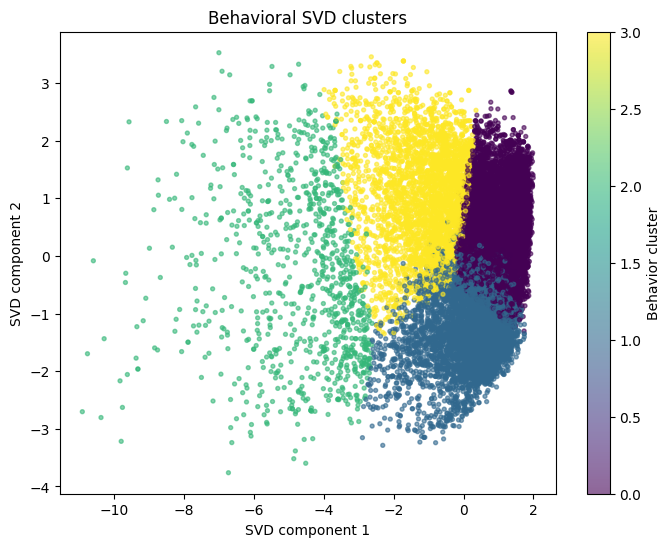

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_pdf["svd_1"],
    plot_pdf["svd_2"],
    c=plot_pdf["behavior_cluster"],
    s=8,
    alpha=0.6
)
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Behavioral SVD clusters")
plt.colorbar(label="Behavior cluster")
plt.show()

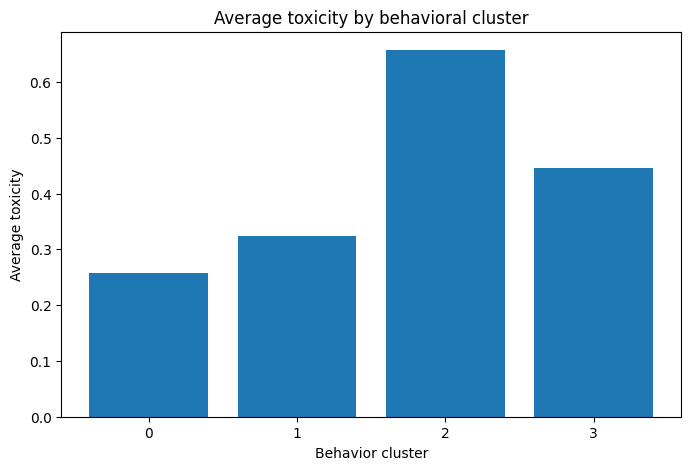

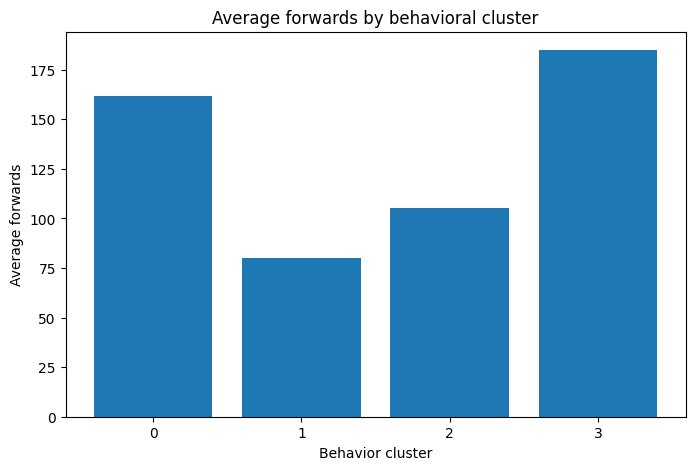

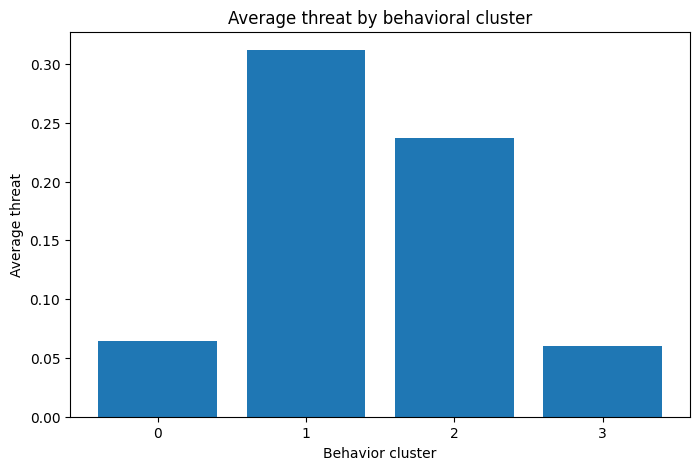

In [19]:
summary_pdf = summary.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(summary_pdf["behavior_cluster"].astype(str), summary_pdf["avg_toxicity"])
plt.xlabel("Behavior cluster")
plt.ylabel("Average toxicity")
plt.title("Average toxicity by behavioral cluster")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_pdf["behavior_cluster"].astype(str), summary_pdf["avg_forwards"])
plt.xlabel("Behavior cluster")
plt.ylabel("Average forwards")
plt.title("Average forwards by behavioral cluster")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_pdf["behavior_cluster"].astype(str), summary_pdf["avg_threat"])
plt.xlabel("Behavior cluster")
plt.ylabel("Average threat")
plt.title("Average threat by behavioral cluster")
plt.show()

In [20]:
OUTPUT_DIR = Path("/kaggle/working/behavioral_svd_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_pdf.to_csv(OUTPUT_DIR / "behavior_cluster_summary.csv", index=False)

representatives.write.mode("overwrite").parquet(
    str(OUTPUT_DIR / "representative_messages_by_cluster")
)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /kaggle/working/behavioral_svd_outputs


## Report interpretation

- Dataset thô rất lớn nên dùng file-level streaming để xử lý trên Kaggle.
- Nhóm lọc ra English political messages có toxicity và forwards đủ cao.
- SVD/PCA áp dụng trên harmful behavioral features, không phải text.
- Component 1 có thể biểu diễn toxicity tổng quát nếu weight lớn ở toxicity/insult/profanity.
- Component 2 có thể biểu diễn threat/identity attack nếu weight lớn ở threat/identity_attack.
- `log_forwards` biểu diễn amplification.
- KMeans trên SVD space giúp phân nhóm các behavioral profiles.
- Cluster có toxicity cao và forwards cao có thể được xem là nhóm nội dung chính trị độc hại có khả năng lan truyền mạnh.